# Import Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud


In [69]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


# Load Dataset

In [70]:
df = pd.read_csv(r"C:\Users\GOD\Downloads\Corona_NLP_train.csv\Corona_NLP_train.csv", encoding="latin1")
df.head()



,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


# EDA

In [71]:
df.tail()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
41152,44951,89903,"Wellington City, New Zealand",14-04-2020,Airline pilots offering to stock supermarket s...,Neutral
41153,44952,89904,NaN,14-04-2020,Response to complaint not provided citing COVI...,Extremely Negative
41154,44953,89905,NaN,14-04-2020,You know itÂs getting tough when @KameronWild...,Positive
41155,44954,89906,NaN,14-04-2020,Is it wrong that the smell of hand sanitizer i...,Neutral
41156,44955,89907,i love you so much || he/him,14-04-2020,@TartiiCat Well new/used Rift S are going for ...,Negative


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


In [73]:
df.columns

Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')

In [74]:
df.shape

(41157, 6)

In [75]:
df.isnull().sum()

UserName            0
ScreenName          0
Location         8590
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [76]:
df['Location'] = df['Location'].fillna(0)

In [77]:
df.isnull().sum()

UserName         0
ScreenName       0
Location         0
TweetAt          0
OriginalTweet    0
Sentiment        0
dtype: int64

# Keep Only Required Columns

In [78]:
df = df[['OriginalTweet', 'Sentiment']]
df.head()


,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,advice Talk to your neighbours family to excha...,Positive
2,Coronavirus Australia: Woolworths to give elde...,Positive
3,My food stock is not the only one which is emp...,Positive
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative


# Convert Sentiment to Binary

In [79]:
df['Sentiment'] = df['Sentiment'].map({
    'Extremely Negative': 0,
    'Negative': 0,
    'Neutral': 1,
    'Positive': 1,
    'Extremely Positive': 1
})

df.head()


,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,1
1,advice Talk to your neighbours family to excha...,1
2,Coronavirus Australia: Woolworths to give elde...,1
3,My food stock is not the only one which is emp...,1
4,"Me, ready to go at supermarket during the #COV...",0


# Text Cleaning Function

In [80]:
def wordopt(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text


In [81]:
df['OriginalTweet'] = df['OriginalTweet'].apply(wordopt)


# Data Visualization

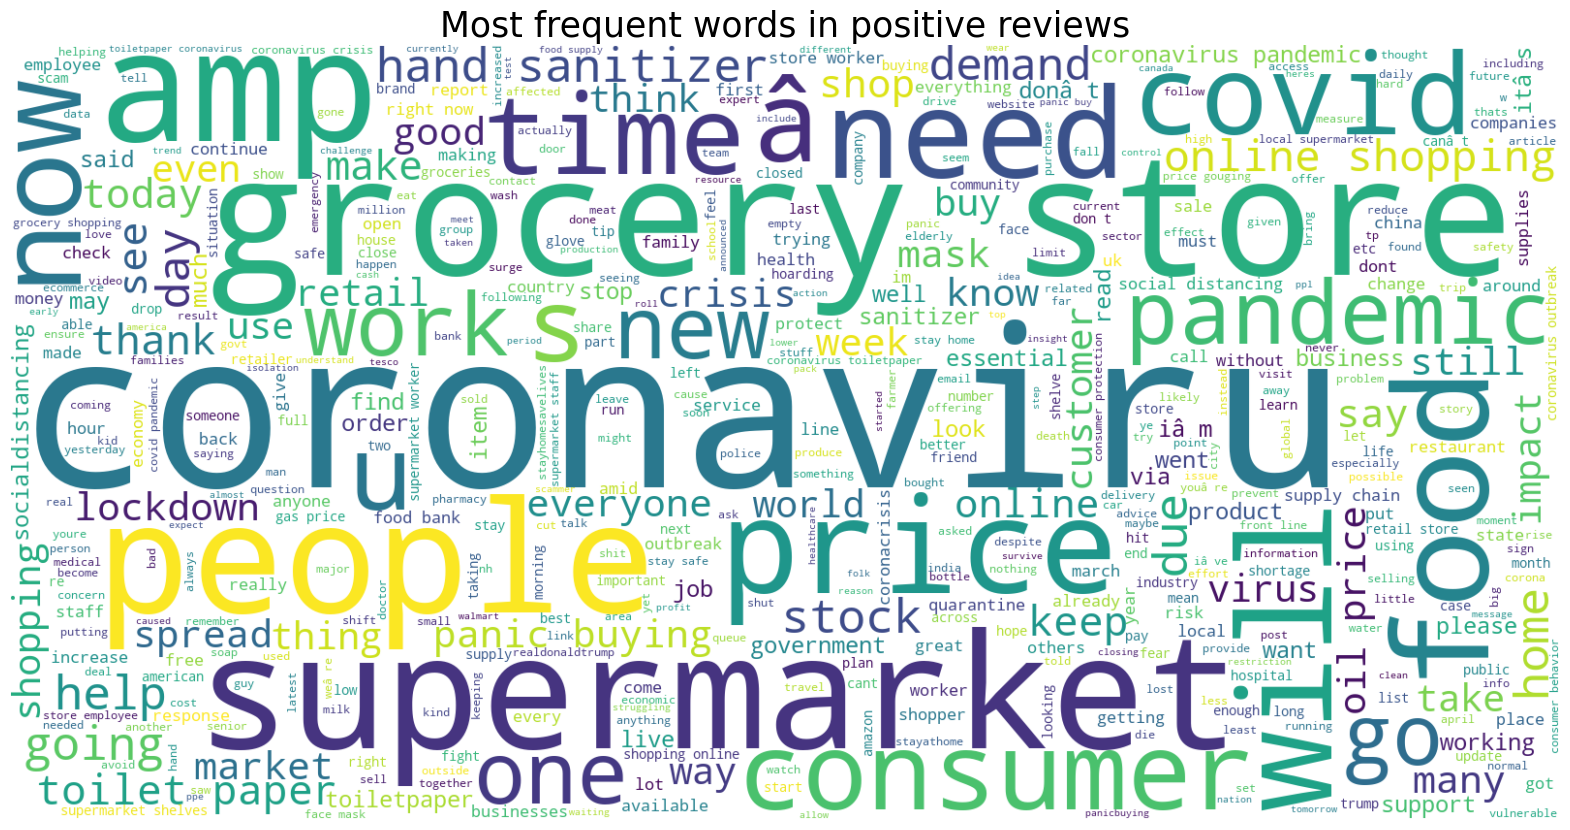

In [82]:
text=' '.join([word for word in df['OriginalTweet']])
plt.figure(figsize=(20,15),facecolor='None')
wordcloud=WordCloud(max_words=500,width=1600,height=800,background_color="white").generate(text)
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in positive reviews', fontsize=25)
plt.show()

# Data Splitting

In [83]:
x = df['OriginalTweet']
y = df['Sentiment']

# x_train, x_test, y_train, y_test = train_test_split(
#     x, y, test_size=0.25, random_state=42
# )


In [84]:
x

0                   menyrbie philgahan chrisitv  and  and 
1        advice talk to your neighbours family to excha...
2        coronavirus australia woolworths to give elder...
3        my food stock is not the only one which is emp...
4        me ready to go at supermarket during the  outb...
                               ...                        
41152    airline pilots offering to stock supermarket s...
41153    response to complaint not provided citing  rel...
41154    you know itâs getting tough when kameronwilds...
41155    is it wrong that the smell of hand sanitizer i...
41156    tartiicat well newused rift s are going for  o...
Name: OriginalTweet, Length: 41157, dtype: object

In [85]:
y

0        1
1        1
2        1
3        1
4        0
        ..
41152    1
41153    0
41154    1
41155    1
41156    0
Name: Sentiment, Length: 41157, dtype: int64

# train–Test Split

In [86]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [87]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(30867,) (10290,) (30867,) (10290,)


# TF-IDF Vectorization

# NLP

In [88]:
vectorization = TfidfVectorizer(stop_words='english')
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)


In [89]:
xv_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 476170 stored elements and shape (30867, 47277)>

In [90]:
xv_train.shape

(30867, 47277)

In [91]:
xv_test.shape

(10290, 47277)

# Model Building

# Logistic Regression Model

In [92]:
LR = LogisticRegression(max_iter=1000)
LR.fit(xv_train, y_train)


LogisticRegression(max_iter=1000)

In [93]:
pred_lr = LR.predict(xv_test)
pred_lr 


array([0, 0, 1, ..., 1, 1, 1])

In [95]:
accuracy_score(y_test, pred_lr)


0.8290573372206025

# DecisionTreeClassifier

In [12]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(xv_train, y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
dt_pred = dt.predict(xv_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))


Decision Tree Accuracy: 0.750728862973761


# RandomForestClassifier

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(xv_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
rf_pred = rf.predict(xv_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8134110787172012


# Prediction & Accuracy

In [28]:
print("LR :", accuracy_score(y_test, pred_lr))
print("DT :", accuracy_score(y_test, dt_pred))
print("RF :", accuracy_score(y_test, rf_pred))

LR : 0.8290573372206025
DT : 0.750728862973761
RF : 0.8134110787172012


In [32]:
pred_lr = LR.predict(xv_test)
print("Accuracy:", accuracy_score(y_test, pred_lr))



Accuracy: 0.8290573372206025


In [30]:
print(confusion_matrix(y_test, pred_lr))

[[2499 1331]
 [ 428 6032]]


In [31]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.65      0.74      3830
           1       0.82      0.93      0.87      6460

    accuracy                           0.83     10290
   macro avg       0.84      0.79      0.81     10290
weighted avg       0.83      0.83      0.82     10290



# Manual Testing

In [33]:
def output_sentiment(n):
    if n == 0:
        return "Negative Tweet"
    else:
        return "Positive Tweet"


In [34]:
def manual_testing(tweet):
    tweet = wordopt(tweet)
    tweet_vector = vectorization.transform([tweet])
    prediction = LR.predict(tweet_vector)
    return output_sentiment(prediction[0])


In [35]:
manual_testing("People are worried about covid cases increasing again")


'Negative Tweet'